In [1]:
#installing the libraries eg depth anything V2 etc and the dependencies.
!pip install torch torchvision --quiet
!pip install transformers --quiet
!pip install matplotlib numpy pillow --quiet

In [2]:
import os
base = "/kaggle/input"
for root, dirs, files in os.walk(base):
    print(f"\nFOLDER: {root}")
    for f in files[:5]:
        print(f"  {f}")
    if len(root.split(os.sep)) > 6:
        break


FOLDER: /kaggle/input

FOLDER: /kaggle/input/datasets

FOLDER: /kaggle/input/datasets/akangaandrew

FOLDER: /kaggle/input/datasets/akangaandrew/hospinav

FOLDER: /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8
  README.roboflow.txt
  data.yaml


In [3]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ─────────────────────────────────────────────
# STATION 3: Build Occupancy Grid
# ─────────────────────────────────────────────

def build_occupancy_grid(image_width, image_height, 
                          bounding_boxes, depth_map, 
                          grid_rows=20, grid_cols=20, 
                          danger_threshold=0.7):
    """
    Convert bounding boxes + depth map into a 2D occupancy grid.
    
    Parameters:
        image_width, image_height : dimensions of the camera frame
        bounding_boxes : list of [x_centre, y_centre, width, height, label]
                         in pixel coordinates (not normalised)
        depth_map      : 2D numpy array same size as image, 
                         values 0.0 to 1.0 where higher = closer
        grid_rows      : how many rows to divide the frame into
        grid_cols      : how many columns to divide the frame into
        danger_threshold: depth value above which an obstacle is dangerous
                          0.7 means only flag obstacles in the closer 30% 
                          of the depth range
    
    Returns:
        grid : 2D numpy array of shape (grid_rows, grid_cols)
               0 = free, 1 = occupied
    """
    
    # Step 1: Create empty grid, all cells start as free
    grid = np.zeros((grid_rows, grid_cols), dtype=int)
    
    # Step 2: Calculate how many pixels each grid cell covers
    cell_height = image_height / grid_rows
    cell_width  = image_width  / grid_cols
    
    # Step 3: For each bounding box, mark its grid cells as occupied
    for box in bounding_boxes:
        x_centre, y_centre, box_w, box_h, label = box
        
        # Convert centre format to corner format
        x_min = int(x_centre - box_w / 2)
        x_max = int(x_centre + box_w / 2)
        y_min = int(y_centre - box_h / 2)
        y_max = int(y_centre + box_h / 2)
        
        # Clamp to image boundaries so we don't go out of bounds
        x_min = max(0, x_min)
        x_max = min(image_width - 1, x_max)
        y_min = max(0, y_min)
        y_max = min(image_height - 1, y_max)
        
        # Step 4: Check depth within this bounding box region
        # Extract the depth values that fall inside this bounding box
        depth_region = depth_map[y_min:y_max, x_min:x_max]
        
        if depth_region.size == 0:
            continue
            
        # Use median depth to avoid being fooled by noisy pixels
        median_depth = np.median(depth_region)
        
        # Step 5: Only mark as occupied if obstacle is close enough to matter
        # Higher depth value = closer to camera in our convention
        if median_depth < danger_threshold:
            continue  # Obstacle is far away, ignore it for now
        
        # Step 6: Find which grid cells this bounding box overlaps
        # Convert pixel coordinates to grid cell indices
        grid_row_min = int(y_min / cell_height)
        grid_row_max = int(y_max / cell_height)
        grid_col_min = int(x_min / cell_width)
        grid_col_max = int(x_max / cell_width)
        
        # Clamp to grid boundaries
        grid_row_min = max(0, grid_row_min)
        grid_row_max = min(grid_rows - 1, grid_row_max)
        grid_col_min = max(0, grid_col_min)
        grid_col_max = min(grid_cols - 1, grid_col_max)
        
        # Step 7: Mark all overlapping cells as occupied
        grid[grid_row_min:grid_row_max+1, 
             grid_col_min:grid_col_max+1] = 1
    
    return grid


# ─────────────────────────────────────────────
# STATION 4: A* Path Planner
# ─────────────────────────────────────────────

def heuristic(current, goal):
    """
    Manhattan distance from current cell to goal cell.
    This is the h(n) you were calculating with your finger on paper.
    
    Parameters:
        current : (row, col) tuple
        goal    : (row, col) tuple
    
    Returns:
        Manhattan distance as integer
    """
    return abs(current[0] - goal[0]) + abs(current[1] - goal[1])


def astar(grid, start, goal):
    """
    A* search on a 2D occupancy grid.
    
    Parameters:
        grid  : 2D numpy array, 0 = free, 1 = occupied
        start : (row, col) tuple - wheelchair position (bottom centre)
        goal  : (row, col) tuple - target position (top centre)
    
    Returns:
        path : list of (row, col) tuples from start to goal
               returns empty list if no path exists
    """
    
    grid_rows, grid_cols = grid.shape
    
    # The open set is a priority queue ordered by f(n)
    # Each entry is: (f_score, g_score, current_position, path_so_far)
    # heapq always pops the smallest f_score first
    open_set = []
    heapq.heappush(open_set, (0, 0, start, [start]))
    
    # Keep track of cells we have already fully explored
    # so we do not visit the same cell twice
    visited = set()
    
    while open_set:
        
        # Pop the cell with the lowest f(n) score
        f_score, g_score, current, path = heapq.heappop(open_set)
        
        # If we reached the goal, return the path
        if current == goal:
            return path
        
        # Skip if we already visited this cell via a better path
        if current in visited:
            continue
        visited.add(current)
        
        # Explore all 4 neighbours: up, down, left, right
        row, col = current
        neighbours = [
            (row - 1, col),  # up
            (row + 1, col),  # down
            (row,     col - 1),  # left
            (row,     col + 1),  # right
        ]
        
        for neighbour in neighbours:
            n_row, n_col = neighbour
            
            # Skip if outside grid boundaries
            if not (0 <= n_row < grid_rows and 0 <= n_col < grid_cols):
                continue
            
            # Skip if occupied (obstacle) or already visited
            if grid[n_row, n_col] == 1 or neighbour in visited:
                continue
            
            # Calculate scores for this neighbour
            new_g = g_score + 1          # one step further from start
            new_h = heuristic(neighbour, goal)  # estimated steps to goal
            new_f = new_g + new_h        # total estimated cost
            
            # Add to open set with updated path
            heapq.heappush(open_set, 
                          (new_f, new_g, neighbour, path + [neighbour]))
    
    # If open set is empty and we never reached goal, no path exists
    return []


# ─────────────────────────────────────────────
# STATION 5: Convert Path to Steering Command
# ─────────────────────────────────────────────

def path_to_steering(path, grid_cols):
    """
    Look at the first few steps of the path and decide 
    which direction to steer.
    
    Parameters:
        path      : list of (row, col) tuples from A*
        grid_cols : total number of grid columns (to find centre)
    
    Returns:
        command : string, one of FORWARD / LEFT / RIGHT / STOP
    """
    
    if not path or len(path) < 2:
        return "STOP"
    
    centre_col = grid_cols // 2
    
    # Look ahead 3 steps to smooth out minor wiggles
    look_ahead = min(4, len(path))
    next_col = path[look_ahead - 1][1]
    
    deviation = next_col - centre_col
    
    if deviation < -2:
        return "LEFT"
    elif deviation > 2:
        return "RIGHT"
    else:
        return "FORWARD"


# ─────────────────────────────────────────────
# VISUALISATION: Show everything on one figure
# ─────────────────────────────────────────────

def visualise(image, grid, path, command, depth_map):
    """
    Display the original image, depth map, occupancy grid, 
    and planned path side by side.
    """
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Original image with bounding boxes
    axes[0].imshow(image)
    axes[0].set_title("Original Frame")
    axes[0].axis("off")
    
    # Panel 2: Depth map
    axes[1].imshow(depth_map, cmap="plasma")
    axes[1].set_title("Depth Map (brighter = closer)")
    axes[1].axis("off")
    
    # Panel 3: Occupancy grid with planned path
    grid_display = np.zeros((*grid.shape, 3))
    
    # Free cells = white
    grid_display[grid == 0] = [1, 1, 1]
    
    # Occupied cells = red
    grid_display[grid == 1] = [1, 0, 0]
    
    # Path cells = green
    for row, col in path:
        grid_display[row, col] = [0, 0.8, 0]
    
    # Start = blue, Goal = yellow
    start_row = grid.shape[0] - 1
    start_col = grid.shape[1] // 2
    goal_row  = 0
    goal_col  = grid.shape[1] // 2
    
    grid_display[start_row, start_col] = [0, 0, 1]
    grid_display[goal_row,  goal_col]  = [1, 1, 0]
    
    axes[2].imshow(grid_display, interpolation="nearest")
    axes[2].set_title(f"Occupancy Grid + Path\nSteering: {command}")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.savefig("pipeline_output.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSteering Command: {command}")

Loading image...
Image size: 640 x 640
Loading annotations...
  Found: sofa at centre (220, 450) size (290 x 315)
  Found: Saline Stand at centre (544, 464) size (192 x 243)
  Found: bed at centre (214, 238) size (79 x 326)
  Found: stool at centre (426, 435) size (92 x 224)
Total objects found: 4

Running Depth Anything V2...
(This may take a minute on first run while model downloads)


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Depth map range after normalisation: 0.000 to 1.000

Building occupancy grid...
Grid built: 0 occupied cells, 400 free cells

Running A* path planner...
Path found: 20 steps

Steering Command: FORWARD

Generating visualisation...


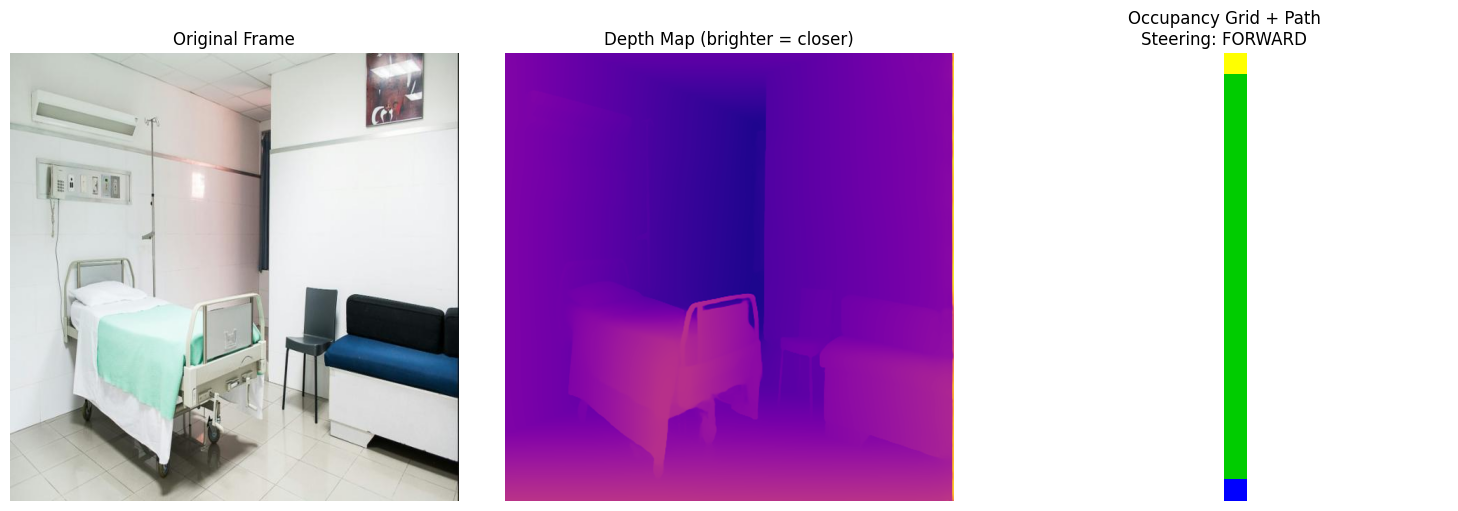


Steering Command: FORWARD

Done. Output saved to pipeline_output.png


In [4]:
import numpy as np
import torch
from PIL import Image
from transformers import pipeline as hf_pipeline
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────────────────
# CONFIGURATION
# Change these paths to match your Kaggle dataset structure
# ─────────────────────────────────────────────────────

# Path to one image from your dataset
IMAGE_PATH = "/kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/valid/images/Screenshot_hospital_jpg.rf.d32ea851f2e90bf63b55cc19f3992184.jpg"

# Path to its corresponding annotation file
LABEL_PATH = "/kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/valid/labels/Screenshot_hospital_jpg.rf.d32ea851f2e90bf63b55cc19f3992184.txt"

# Grid dimensions
GRID_ROWS = 20
GRID_COLS = 20

# Depth threshold: obstacles with depth above this are marked dangerous
# 0.7 means the closest 30% of the depth range is dangerous
DANGER_THRESHOLD = 0.7

# Class names in order matching your dataset
CLASS_NAMES = [
    "Monitor", "bed", "sofa", 
    "tools_table", "stool", 
    "Saline Stand", "chair", "bin"
]


# ─────────────────────────────────────────────────────
# STEP 1: Load the image
# ─────────────────────────────────────────────────────

print("Loading image...")
image_pil = Image.open(IMAGE_PATH).convert("RGB")
image_np  = np.array(image_pil)

image_height, image_width = image_np.shape[:2]
print(f"Image size: {image_width} x {image_height}")


# ─────────────────────────────────────────────────────
# STEP 2: Load and parse the annotation file
# Convert from YOLOv8 normalised format to pixel coordinates
# ─────────────────────────────────────────────────────

print("Loading annotations...")

def load_yolo_annotations(label_path, image_width, image_height, class_names):
    """
    YOLOv8 stores annotations as:
        class_id  x_centre  y_centre  width  height
    All values are normalised 0.0 to 1.0 relative to image size.
    
    We convert them to absolute pixel coordinates here.
    """
    bounding_boxes = []
    
    with open(label_path, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        
        class_id = int(parts[0])
        x_centre_norm = float(parts[1])
        y_centre_norm = float(parts[2])
        width_norm    = float(parts[3])
        height_norm   = float(parts[4])
        
        # Convert normalised to pixel coordinates
        x_centre_px = x_centre_norm * image_width
        y_centre_px = y_centre_norm * image_height
        width_px    = width_norm    * image_width
        height_px   = height_norm   * image_height
        
        label = class_names[class_id] if class_id < len(class_names) else str(class_id)
        
        bounding_boxes.append([
            x_centre_px, y_centre_px, 
            width_px, height_px, 
            label
        ])
        
        print(f"  Found: {label} at centre "
              f"({x_centre_px:.0f}, {y_centre_px:.0f}) "
              f"size ({width_px:.0f} x {height_px:.0f})")
    
    return bounding_boxes

bounding_boxes = load_yolo_annotations(
    LABEL_PATH, image_width, image_height, CLASS_NAMES
)
print(f"Total objects found: {len(bounding_boxes)}")


# ─────────────────────────────────────────────────────
# STEP 3: Run Depth Anything V2
# ─────────────────────────────────────────────────────

print("\nRunning Depth Anything V2...")
print("(This may take a minute on first run while model downloads)")

# Load the depth estimation pipeline from HuggingFace
# We use the Small model to keep it fast on Kaggle's free GPU
depth_estimator = hf_pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1
)

# Run depth estimation on our image
depth_output = depth_estimator(image_pil)

# Extract the depth map and resize to match our image
depth_raw = depth_output["depth"]
depth_pil = depth_raw.resize(
    (image_width, image_height), 
    Image.BILINEAR
)
depth_array = np.array(depth_pil, dtype=np.float32)

# Normalise depth to 0.0 - 1.0 range
# IMPORTANT: Depth Anything V2 outputs larger values for CLOSER objects
# We preserve this convention: higher value = closer = more dangerous
depth_min = depth_array.min()
depth_max = depth_array.max()
depth_normalised = (depth_array - depth_min) / (depth_max - depth_min + 1e-8)

print(f"Depth map range after normalisation: "
      f"{depth_normalised.min():.3f} to {depth_normalised.max():.3f}")


# ─────────────────────────────────────────────────────
# STEP 4: Build Occupancy Grid
# ─────────────────────────────────────────────────────

print("\nBuilding occupancy grid...")

grid = build_occupancy_grid(
    image_width      = image_width,
    image_height     = image_height,
    bounding_boxes   = bounding_boxes,
    depth_map        = depth_normalised,
    grid_rows        = GRID_ROWS,
    grid_cols        = GRID_COLS,
    danger_threshold = DANGER_THRESHOLD
)

occupied_count = np.sum(grid == 1)
free_count     = np.sum(grid == 0)
print(f"Grid built: {occupied_count} occupied cells, {free_count} free cells")


# ─────────────────────────────────────────────────────
# STEP 5: Run A* Path Planner
# ─────────────────────────────────────────────────────

print("\nRunning A* path planner...")

# Start = bottom centre (wheelchair position)
start = (GRID_ROWS - 1, GRID_COLS // 2)

# Goal = top centre (move forward down corridor)
goal  = (0, GRID_COLS // 2)

# Make sure start and goal cells are not marked as occupied
# (they must be free for A* to work)
grid[start[0], start[1]] = 0
grid[goal[0],  goal[1]]  = 0

path = astar(grid, start, goal)

if path:
    print(f"Path found: {len(path)} steps")
else:
    print("No path found - corridor is completely blocked")


# ─────────────────────────────────────────────────────
# STEP 6: Get Steering Command
# ─────────────────────────────────────────────────────

command = path_to_steering(path, GRID_COLS)
print(f"\nSteering Command: {command}")


# ─────────────────────────────────────────────────────
# STEP 7: Visualise Everything
# ─────────────────────────────────────────────────────

print("\nGenerating visualisation...")

visualise(
    image     = image_np,
    grid      = grid,
    path      = path,
    command   = command,
    depth_map = depth_normalised
)

print("\nDone. Output saved to pipeline_output.png")